# Compare Models: Reconstruction Errors and MST Metrics
Load summary JSON outputs created by notebook 11 and compare models.

In [65]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

In [66]:
project_root = Path.cwd().resolve().parent
results_root = project_root / "results"

DATASET_NAME = "data_00_20_w252_s5"
dataset_dir = results_root / DATASET_NAME
analysis_dir = dataset_dir / "reconstruction_analysis"
comparison_dir = dataset_dir / "comparison"
comparison_dir.mkdir(parents=True, exist_ok=True)

if not dataset_dir.exists():
    available = [p.name for p in results_root.iterdir() if p.is_dir()]
    raise FileNotFoundError(f"Dataset not found: {dataset_dir}. Available: {available}")

if not analysis_dir.exists():
    raise FileNotFoundError(f"Missing reconstruction_analysis folder: {analysis_dir}")

model_dirs = sorted([p for p in analysis_dir.iterdir() if p.is_dir()])
model_names = [p.name for p in model_dirs]

print(f"Models found ({len(model_names)}): {model_names}")

Models found (24): ['AE_100dim_0001', 'AE_10dim_0001', 'AE_150dim_0001', 'AE_20dim_0001', 'AE_3dim_0001', 'AE_50dim_0001', 'AE_614dim_0001', 'AE_70dim_0001', 'linearAE_100dim_0001', 'linearAE_10dim_0001', 'linearAE_150dim_0001', 'linearAE_20dim_0001', 'linearAE_3dim_0001', 'linearAE_50dim_0001', 'linearAE_614dim_0001', 'linearAE_70dim_0001', 'PCA_100dim', 'PCA_10dim', 'PCA_150dim', 'PCA_20dim', 'PCA_3dim', 'PCA_50dim', 'PCA_614dim', 'PCA_70dim']


In [67]:
import re


def load_json(path: Path):
    with open(path, "r") as f:
        return json.load(f)


def flatten_metric_stats(metrics_dict, prefix=""):
    flat = {}
    for metric, stats in metrics_dict.items():
        for stat, val in stats.items():
            key = f"{prefix}{metric}_{stat}"
            flat[key] = val
    return flat


def load_model_stats(model_dir: Path):
    records = []

    errors_path = model_dir / "reconstruction_errors.json"
    if errors_path.exists():
        payload = load_json(errors_path)

        if isinstance(payload, dict):
            record = {"model": model_dir.name}
            errors_block = payload.get("reconstruction_errors")
            mst_block = payload.get("mst_metrics")

            if errors_block is None and "MSE" in payload:
                errors_block = payload

            if errors_block is not None:
                record.update(flatten_metric_stats(errors_block, prefix="err_"))
            else:
                print(f"Missing reconstruction_errors block for {model_dir.name}")

            if mst_block is not None:
                record.update(flatten_metric_stats(mst_block, prefix="mst_"))
            else:
                print(f"Missing mst_metrics block for {model_dir.name}")

            records.append(record)
        elif isinstance(payload, list):
            if payload:
                sweep_df = pd.DataFrame(payload)
                for _, row in sweep_df.iterrows():
                    k = None
                    if "n_components" in row and pd.notna(row["n_components"]):
                        k = int(row["n_components"])

                    model_name = f"{model_dir.name}_{k}" if k is not None else model_dir.name
                    record = {"model": model_name}

                    err_block = None
                    row_errs = row.get("reconstruction_errors")
                    if isinstance(row_errs, dict):
                        err_block = row_errs
                    else:
                        err_block = {}
                        if "MSE_mean" in row and pd.notna(row["MSE_mean"]):
                            err_block.setdefault("MSE", {})["mean"] = float(row["MSE_mean"])
                        if "MAE_mean" in row and pd.notna(row["MAE_mean"]):
                            err_block.setdefault("MAE", {})["mean"] = float(row["MAE_mean"])
                        if "Frobenius_mean" in row and pd.notna(row["Frobenius_mean"]):
                            err_block.setdefault("Frobenius", {})["mean"] = float(row["Frobenius_mean"])
                        if not err_block:
                            err_block = None

                    if err_block is not None:
                        record.update(flatten_metric_stats(err_block, prefix="err_"))
                    else:
                        print(f"Missing reconstruction_errors block for {model_name}")

                    if "mean_explained_variance" in row and pd.notna(row["mean_explained_variance"]):
                        record["pca_mean_explained_variance"] = float(row["mean_explained_variance"])
                    if k is not None:
                        record["pca_selected_k"] = k

                    records.append(record)
            else:
                print(f"Empty reconstruction_errors list for {model_dir.name}")
        else:
            print(f"Unexpected reconstruction_errors format for {model_dir.name}")
    else:
        print(f"Missing reconstruction_errors.json for {model_dir.name}")

    return records


def parse_model_name(model_name: str):
    method_raw = model_name.split("_")[0]
    method_map = {"pca": "PCA", "linearae": "linearAE", "ae": "AE"}
    method = method_map.get(method_raw.lower(), method_raw)

    if method == "linearAE" and "biasfalse" in model_name.lower():
        method = "linearAE_biasFalse"
    if method == "AE" and "relu" in model_name.lower():
        method = "AE_ReLU"

    k = None
    dim_match = re.search(r"(\d+)\s*dim", model_name, flags=re.IGNORECASE)
    if dim_match:
        k = int(dim_match.group(1))
    else:
        after_method = re.search(r"^[^_]+_(\d+)(?:_|$)", model_name)
        if after_method:
            k = int(after_method.group(1))
        else:
            any_num = re.search(r"(\d+)", model_name)
            if any_num:
                k = int(any_num.group(1))

    return method, k


def extract_run_id(model_name: str, k):
    nums = [int(x) for x in re.findall(r"(\d+)", model_name)]
    if not nums:
        return None
    if k is None:
        return nums[-1]
    for value in reversed(nums):
        if value != k:
            return value
    return None


method_order = ["PCA", "linearAE_biasFalse", "linearAE", "AE", "AE_ReLU"]
method_rank = {m: i for i, m in enumerate(method_order)}


def model_sort_key(model_name: str):
    method, k = parse_model_name(model_name)
    run_id = extract_run_id(model_name, k)
    method_pos = method_rank.get(method, len(method_order))
    k_pos = k if k is not None else float("inf")
    run_pos = run_id if run_id is not None else float("inf")
    return (method_pos, k_pos, run_pos, model_name.lower())


def sort_by_method_k(df: pd.DataFrame):
    ordered_index = sorted(df.index, key=model_sort_key)
    return df.loc[ordered_index]


print(model_dirs)
records_nested = [load_model_stats(p) for p in model_dirs]
records = [record for sublist in records_nested for record in sublist]
stats_df = pd.DataFrame(records).set_index("model").sort_index()
stats_df = sort_by_method_k(stats_df)
stats_df

[WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGETTO_TESI_DYLAN/results/data_00_20_w252_s5/reconstruction_analysis/AE_100dim_0001'), WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGETTO_TESI_DYLAN/results/data_00_20_w252_s5/reconstruction_analysis/AE_10dim_0001'), WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGETTO_TESI_DYLAN/results/data_00_20_w252_s5/reconstruction_analysis/AE_150dim_0001'), WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGETTO_TESI_DYLAN/results/data_00_20_w252_s5/reconstruction_analysis/AE_20dim_0001'), WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGETTO_TESI_DYLAN/results/data_00_20_w252_s5/reconstruction_analysis/AE_3dim_0001'), WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGETTO_TESI_DYLAN/results/data_00_20_w252_s5/reconstruction_analysis/AE_50dim_0001'), WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGETTO_TESI_D

,err_MSE_mean,err_MSE_std,err_MSE_min,err_MSE_median,err_MSE_max,err_MAE_mean,err_MAE_std,err_MAE_min,err_MAE_median,err_MAE_max,err_Frobenius_mean,err_Frobenius_std,err_Frobenius_min,err_Frobenius_median,err_Frobenius_max,mst_edge_overlap_pct_count,mst_edge_overlap_pct_mean,mst_edge_overlap_pct_std,mst_edge_overlap_pct_min,mst_edge_overlap_pct_25%,mst_edge_overlap_pct_50%,mst_edge_overlap_pct_75%,mst_edge_overlap_pct_max,mst_edge_jaccard_pct_count,mst_edge_jaccard_pct_mean,...,mst_avg_path_len_unweighted_max,mst_avg_path_len_unweighted_recon_count,mst_avg_path_len_unweighted_recon_mean,mst_avg_path_len_unweighted_recon_std,mst_avg_path_len_unweighted_recon_min,mst_avg_path_len_unweighted_recon_25%,mst_avg_path_len_unweighted_recon_50%,mst_avg_path_len_unweighted_recon_75%,mst_avg_path_len_unweighted_recon_max,mst_avg_path_len_unweighted_diff_count,mst_avg_path_len_unweighted_diff_mean,mst_avg_path_len_unweighted_diff_std,mst_avg_path_len_unweighted_diff_min,mst_avg_path_len_unweighted_diff_25%,mst_avg_path_len_unweighted_diff_50%,mst_avg_path_len_unweighted_diff_75%,mst_avg_path_len_unweighted_diff_max,mst_betweenness_topk_overlap_pct_count,mst_betweenness_topk_overlap_pct_mean,mst_betweenness_topk_overlap_pct_std,mst_betweenness_topk_overlap_pct_min,mst_betweenness_topk_overlap_pct_25%,mst_betweenness_topk_overlap_pct_50%,mst_betweenness_topk_overlap_pct_75%,mst_betweenness_topk_overlap_pct_max
model,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
PCA_3dim,0.015654,0.003802,0.011167,0.013837,0.022951,0.097328,0.011514,0.082711,0.091988,0.118322,12.425264,1.471581,10.567320,11.762890,15.149745,133.0,21.455153,4.127749,12.121212,19.191919,20.202020,24.242424,30.303030,133.0,12.076416,...,10.050707,133.0,5.323097,0.880537,4.387677,4.699596,4.856970,6.305051,6.786263,133.0,2.221151,1.378278,0.118384,0.983838,2.078990,3.297778,5.646869,133.0,18.421053,9.679884,0.0,10.0,20.0,30.0,50.0
PCA_10dim,0.014434,0.003392,0.010672,0.012555,0.021128,0.093429,0.010128,0.081265,0.088419,0.112565,11.936692,1.367243,10.330544,11.204948,14.535530,133.0,23.999392,2.926892,16.161616,22.222222,24.242424,26.262626,31.313131,133.0,13.667175,...,10.050707,133.0,5.405459,0.499488,4.486061,5.160606,5.429293,5.632323,7.278182,133.0,1.853221,1.276723,0.004848,0.720606,1.824242,2.759596,4.712525,133.0,17.293233,10.159920,0.0,10.0,20.0,20.0,40.0
PCA_20dim,0.013783,0.003192,0.010260,0.012090,0.020142,0.091010,0.009276,0.079720,0.086918,0.108526,11.666333,1.317587,10.129076,10.995663,14.192333,133.0,22.563986,2.568913,17.171717,21.212121,22.222222,24.242424,30.303030,133.0,12.740322,...,10.050707,133.0,5.225620,0.411111,4.620000,4.877374,5.205051,5.484646,6.584242,133.0,1.944259,1.316206,0.006667,0.780000,1.876768,2.833939,5.000000,133.0,23.834586,9.022011,0.0,20.0,20.0,30.0,50.0
PCA_50dim,0.011900,0.002544,0.009000,0.010457,0.016805,0.084785,0.008445,0.074439,0.080710,0.100430,10.849795,1.136613,9.486795,10.225934,12.963513,133.0,22.427280,4.320988,14.141414,19.191919,23.232323,26.262626,30.303030,133.0,12.695740,...,10.050707,133.0,5.912225,0.501959,4.831515,5.618990,5.827071,6.188283,7.542222,133.0,1.318580,1.000638,0.031111,0.547475,1.120808,1.901010,4.007677,133.0,28.496241,12.997450,0.0,20.0,30.0,30.0,60.0
PCA_70dim,0.011277,0.002374,0.008616,0.009902,0.015974,0.082360,0.008129,0.072486,0.077906,0.097658,10.563649,1.089182,9.282233,9.951007,12.638958,133.0,21.622237,4.524213,13.131313,17.171717,22.222222,24.242424,31.313131,133.0,12.193204,...,10.050707,133.0,5.717389,0.332704,4.828283,5.526667,5.730909,5.944444,6.688283,133.0,1.450540,1.086117,0.002424,0.423636,1.298384,2.330303,3.961010,133.0,31.052632,13.886071,0.0,20.0,30.0,40.0,60.0
PCA_100dim,0.010010,0.001871,0.007702,0.008953,0.013842,0.077614,0.007002,0.068400,0.073781,0.091337,9.963338,0.915076,8.776223,9.462016,11.765113,133.0,22.974102,5.815434,12.121212,16.161616,24.242424,27.272727,33.333333,133.0,13.097849,...,10.050707,133.0,5.837140,0.749300,4.414545,5.369697,5.982828,6.417172,7.04848

In [68]:
err_metrics = ["MSE", "MAE", "Frobenius"]

available_err_metrics = [
    m for m in err_metrics if f"err_{m}_mean" in stats_df.columns
]
if not available_err_metrics:
    raise KeyError("No reconstruction error metrics found. Check JSON files.")

err_means = pd.DataFrame(
    {m: stats_df[f"err_{m}_mean"] for m in available_err_metrics},
    index=stats_df.index,
)
err_stds = pd.DataFrame(
    {m: stats_df[f"err_{m}_std"] for m in available_err_metrics},
    index=stats_df.index,
)

def reshape_to_matrix(series_or_df, metric_name):
    if isinstance(series_or_df, pd.DataFrame):
        df_temp = series_or_df[[metric_name]].copy()
    else:
        df_temp = series_or_df.to_frame(name=metric_name)

    df_flat = df_temp.reset_index()
    model_col = "model" if "model" in df_flat.columns else df_flat.columns[0]
    df_flat[["method", "K"]] = df_flat[model_col].apply(
        lambda x: pd.Series(parse_model_name(x))
    )
    df_flat["K"] = pd.to_numeric(df_flat["K"], errors="coerce")
    df_flat = df_flat.dropna(subset=["method", "K"]).copy()

    # If multiple runs exist for the same method/K, average them.
    grouped = (
        df_flat.groupby(["method", "K"], as_index=False)[metric_name]
        .mean()
    )
    matrix_df = grouped.pivot(index="method", columns="K", values=metric_name)

    ordered_methods = [m for m in method_order if m in matrix_df.index]
    ordered_methods += [m for m in matrix_df.index if m not in ordered_methods]
    matrix_df = matrix_df.reindex(ordered_methods)
    matrix_df = matrix_df.reindex(sorted(matrix_df.columns), axis=1)
    return matrix_df

def combine_mean_std(means_df, stds_df, metric_name, precision=2):
    mean_mat = reshape_to_matrix(means_df, metric_name)
    std_mat = reshape_to_matrix(stds_df, metric_name)
    mean_mat, std_mat = mean_mat.align(std_mat)

    def fmt(m, s):
        if pd.isna(m):
            return np.nan
        mean_str = f"{m:.{precision}e}"
        if pd.isna(s):
            return mean_str
        std_str = f"{s:.{precision}e}"
        return f"{mean_str} +/- {std_str}"

    combined = mean_mat.astype(object)
    for row in mean_mat.index:
        for col in mean_mat.columns:
            combined.loc[row, col] = fmt(mean_mat.loc[row, col], std_mat.loc[row, col])
    return combined

for metric in available_err_metrics:
    print(f"\n" + "="*40)
    print(f" METRICA: {metric}")
    print("="*40)

    combined = combine_mean_std(err_means, err_stds, metric)
    display(combined)
    out_path = comparison_dir / f"err_{metric}_mean_std.csv"
    combined.to_csv(out_path)

err_ranks = err_means.rank(axis=0, ascending=True)
err_ranks["avg_rank"] = err_ranks.mean(axis=1)


 METRICA: MSE


K,3,10,20,50,70,100,150,614
method,,,,,,,,
PCA,1.57e-02 +/- 3.80e-03,1.44e-02 +/- 3.39e-03,1.38e-02 +/- 3.19e-03,1.19e-02 +/- 2.54e-03,1.13e-02 +/- 2.37e-03,1.00e-02 +/- 1.87e-03,8.43e-03 +/- 1.47e-03,5.50e-03 +/- 1.00e-03
linearAE,1.59e-02 +/- 3.88e-03,1.46e-02 +/- 3.59e-03,1.38e-02 +/- 3.21e-03,1.28e-02 +/- 2.74e-03,1.28e-02 +/- 2.81e-03,1.27e-02 +/- 2.72e-03,1.27e-02 +/- 2.80e-03,1.27e-02 +/- 2.75e-03
AE,1.79e-02 +/- 5.88e-03,1.58e-02 +/- 3.59e-03,1.61e-02 +/- 4.10e-03,1.63e-02 +/- 3.62e-03,1.66e-02 +/- 3.37e-03,1.60e-02 +/- 4.17e-03,1.62e-02 +/- 4.33e-03,1.58e-02 +/- 4.06e-03



 METRICA: MAE


K,3,10,20,50,70,100,150,614
method,,,,,,,,
PCA,9.73e-02 +/- 1.15e-02,9.34e-02 +/- 1.01e-02,9.10e-02 +/- 9.28e-03,8.48e-02 +/- 8.44e-03,8.24e-02 +/- 8.13e-03,7.76e-02 +/- 7.00e-03,7.11e-02 +/- 5.95e-03,5.76e-02 +/- 5.00e-03
linearAE,9.79e-02 +/- 1.10e-02,9.41e-02 +/- 1.07e-02,9.13e-02 +/- 9.24e-03,8.78e-02 +/- 8.29e-03,8.78e-02 +/- 8.57e-03,8.76e-02 +/- 8.29e-03,8.76e-02 +/- 8.56e-03,8.76e-02 +/- 8.38e-03
AE,1.05e-01 +/- 1.81e-02,9.83e-02 +/- 1.07e-02,9.82e-02 +/- 1.05e-02,9.96e-02 +/- 1.01e-02,1.01e-01 +/- 9.58e-03,9.85e-02 +/- 1.19e-02,9.86e-02 +/- 1.20e-02,9.80e-02 +/- 1.15e-02



 METRICA: Frobenius


K,3,10,20,50,70,100,150,614
method,,,,,,,,
PCA,1.24e+01 +/- 1.47e+00,1.19e+01 +/- 1.37e+00,1.17e+01 +/- 1.32e+00,1.08e+01 +/- 1.14e+00,1.06e+01 +/- 1.09e+00,9.96e+00 +/- 9.15e-01,9.15e+00 +/- 7.86e-01,7.39e+00 +/- 6.60e-01
linearAE,1.25e+01 +/- 1.49e+00,1.20e+01 +/- 1.44e+00,1.17e+01 +/- 1.32e+00,1.12e+01 +/- 1.18e+00,1.12e+01 +/- 1.21e+00,1.12e+01 +/- 1.17e+00,1.12e+01 +/- 1.21e+00,1.12e+01 +/- 1.18e+00
AE,1.32e+01 +/- 2.11e+00,1.25e+01 +/- 1.39e+00,1.26e+01 +/- 1.56e+00,1.27e+01 +/- 1.38e+00,1.28e+01 +/- 1.29e+00,1.26e+01 +/- 1.59e+00,1.26e+01 +/- 1.65e+00,1.25e+01 +/- 1.57e+00


In [69]:
mst_metrics = [
    "edge_overlap_pct",
    "edge_jaccard_pct",
    "degree_l1",
    "avg_path_len_diff",
    "avg_path_len_unweighted_diff",
    "betweenness_topk_overlap_pct",
]

available_mst_metrics = [
    m for m in mst_metrics if f"mst_{m}_mean" in stats_df.columns
]
if not available_mst_metrics:
    raise KeyError("No MST metrics found. Check JSON files.")

mst_means = pd.DataFrame(
    {m: stats_df[f"mst_{m}_mean"] for m in available_mst_metrics},
    index=stats_df.index,
)
mst_stds = pd.DataFrame(index=stats_df.index)
for m in available_mst_metrics:
    std_col = f"mst_{m}_std"
    if std_col in stats_df.columns:
        mst_stds[m] = stats_df[std_col]
    else:
        mst_stds[m] = np.nan

for metric in available_mst_metrics:
    print(f"\n" + "="*40)
    print(f" METRICA: {metric}")
    print("="*40)

    combined = combine_mean_std(mst_means, mst_stds, metric)
    display(combined)
    out_path = comparison_dir / f"mst_{metric}_mean_std.csv"
    combined.to_csv(out_path)


 METRICA: edge_overlap_pct


K,3,10,20,50,70,100,150,614
method,,,,,,,,
PCA,2.15e+01 +/- 4.13e+00,2.40e+01 +/- 2.93e+00,2.26e+01 +/- 2.57e+00,2.24e+01 +/- 4.32e+00,2.16e+01 +/- 4.52e+00,2.30e+01 +/- 5.82e+00,2.34e+01 +/- 4.89e+00,2.98e+01 +/- 5.51e+00
linearAE,2.34e+01 +/- 3.86e+00,2.31e+01 +/- 2.16e+00,2.23e+01 +/- 2.57e+00,2.19e+01 +/- 2.52e+00,2.23e+01 +/- 2.77e+00,2.21e+01 +/- 2.58e+00,2.17e+01 +/- 2.52e+00,2.21e+01 +/- 2.43e+00
AE,2.52e+01 +/- 2.35e+00,2.31e+01 +/- 3.10e+00,2.51e+01 +/- 2.66e+00,2.36e+01 +/- 2.19e+00,2.48e+01 +/- 2.96e+00,2.43e+01 +/- 2.60e+00,2.43e+01 +/- 2.77e+00,2.30e+01 +/- 2.06e+00



 METRICA: edge_jaccard_pct


K,3,10,20,50,70,100,150,614
method,,,,,,,,
PCA,1.21e+01 +/- 2.60e+00,1.37e+01 +/- 1.89e+00,1.27e+01 +/- 1.65e+00,1.27e+01 +/- 2.73e+00,1.22e+01 +/- 2.85e+00,1.31e+01 +/- 3.68e+00,1.34e+01 +/- 3.16e+00,1.77e+01 +/- 3.80e+00
linearAE,1.33e+01 +/- 2.46e+00,1.31e+01 +/- 1.38e+00,1.26e+01 +/- 1.64e+00,1.23e+01 +/- 1.60e+00,1.26e+01 +/- 1.76e+00,1.24e+01 +/- 1.64e+00,1.22e+01 +/- 1.59e+00,1.25e+01 +/- 1.54e+00
AE,1.44e+01 +/- 1.53e+00,1.31e+01 +/- 1.98e+00,1.44e+01 +/- 1.74e+00,1.34e+01 +/- 1.40e+00,1.42e+01 +/- 1.93e+00,1.39e+01 +/- 1.69e+00,1.39e+01 +/- 1.80e+00,1.30e+01 +/- 1.32e+00



 METRICA: degree_l1


...

K,3,10,20,50,70,100,150,614
method,,,,,,,,
PCA,1.56e+00 +/- 8.78e-01,1.15e+00 +/- 8.93e-01,1.25e+00 +/- 9.11e-01,7.59e-01 +/- 6.54e-01,8.33e-01 +/- 7.33e-01,6.73e-01 +/- 4.95e-01,5.67e-01 +/- 6.05e-01,5.41e-01 +/- 5.74e-01
linearAE,1.11e+00 +/- 7.43e-01,9.89e-01 +/- 8.96e-01,1.16e+00 +/- 8.00e-01,7.90e-01 +/- 7.29e-01,9.43e-01 +/- 6.44e-01,8.25e-01 +/- 6.71e-01,9.36e-01 +/- 6.24e-01,8.04e-01 +/- 6.95e-01
AE,1.16e+00 +/- 8.20e-01,9.86e-01 +/- 6.82e-01,7.46e-01 +/- 5.91e-01,1.12e+00 +/- 6.66e-01,1.28e+00 +/- 7.17e-01,9.60e-01 +/- 5.97e-01,1.06e+00 +/- 6.87e-01,1.12e+00 +/- 7.14e-01



 METRICA: avg_path_len_unweighted_diff


K,3,10,20,50,70,100,150,614
method,,,,,,,,
PCA,2.22e+00 +/- 1.38e+00,1.85e+00 +/- 1.28e+00,1.94e+00 +/- 1.32e+00,1.32e+00 +/- 1.00e+00,1.45e+00 +/- 1.09e+00,1.34e+00 +/- 7.74e-01,1.07e+00 +/- 8.94e-01,8.65e-01 +/- 8.72e-01
linearAE,1.98e+00 +/- 1.23e+00,1.85e+00 +/- 1.30e+00,1.87e+00 +/- 1.30e+00,1.51e+00 +/- 1.11e+00,1.58e+00 +/- 9.61e-01,1.46e+00 +/- 1.06e+00,1.55e+00 +/- 9.66e-01,1.45e+00 +/- 1.12e+00
AE,1.77e+00 +/- 1.23e+00,1.48e+00 +/- 1.13e+00,1.17e+00 +/- 1.05e+00,1.62e+00 +/- 1.13e+00,1.76e+00 +/- 1.24e+00,1.43e+00 +/- 1.08e+00,1.56e+00 +/- 1.16e+00,1.75e+00 +/- 1.09e+00



 METRICA: betweenness_topk_overlap_pct


K,3,10,20,50,70,100,150,614
method,,,,,,,,
PCA,1.84e+01 +/- 9.68e+00,1.73e+01 +/- 1.02e+01,2.38e+01 +/- 9.02e+00,2.85e+01 +/- 1.30e+01,3.11e+01 +/- 1.39e+01,3.44e+01 +/- 1.01e+01,3.55e+01 +/- 9.65e+00,4.44e+01 +/- 1.50e+01
linearAE,2.20e+01 +/- 1.09e+01,2.16e+01 +/- 1.12e+01,2.66e+01 +/- 9.04e+00,2.60e+01 +/- 9.29e+00,2.59e+01 +/- 9.54e+00,2.59e+01 +/- 9.13e+00,2.82e+01 +/- 1.01e+01,2.74e+01 +/- 1.01e+01
AE,2.26e+01 +/- 1.06e+01,2.70e+01 +/- 8.70e+00,2.82e+01 +/- 9.20e+00,2.78e+01 +/- 8.91e+00,2.76e+01 +/- 8.09e+00,2.89e+01 +/- 9.59e+00,3.08e+01 +/- 1.02e+01,2.75e+01 +/- 1.01e+01


# K-based comparison plots
Build plots for error metrics across K and methods.

In [70]:
import re


def parse_model_name(model_name: str):
    method_raw = model_name.split("_")[0]
    method_map = {"pca": "PCA", "linearae": "linearAE", "ae": "AE"}
    method = method_map.get(method_raw.lower(), method_raw)

    if method == "linearAE" and "biasfalse" in model_name.lower():
        method = "linearAE_biasFalse"
    if method == "AE" and "relu" in model_name.lower():
        method = "AE_ReLU"

    match = re.search(r"(\d+)\s*dim", model_name, flags=re.IGNORECASE)
    if not match:
        match = re.search(r"_(\d+)(?:_|$)", model_name)
    k = int(match.group(1)) if match else None

    return method, k


model_meta = []
for model in stats_df.index:
    method, k = parse_model_name(model)
    model_meta.append({"model": model, "method": method, "K": k})

meta_df = pd.DataFrame(model_meta).set_index("model")

err_by_model = err_means.join(meta_df)
err_by_model = err_by_model.dropna(subset=["K", "method"]).copy()
err_by_model["K"] = err_by_model["K"].astype(int)

if err_by_model.empty:
    raise ValueError("No valid models with parsed K were found.")

err_long = err_by_model.melt(
    id_vars=["method", "K"],
    value_vars=available_err_metrics,
    var_name="metric",
    value_name="error",
)

method_order = ["PCA", "linearAE_biasFalse", "linearAE", "AE", "AE_ReLU"]
methods = [m for m in method_order if m in err_long["method"].unique()]
if not methods:
    methods = sorted(err_long["method"].unique())

ks_sorted = sorted(err_long["K"].unique())

method_labels = {
    "PCA": "PCA",
    "linearAE_biasFalse": "LinearAE (biasFalse)",
    "linearAE": "LinearAE",
    "AE": "AE",
    "AE_ReLU": "AE (ReLU)",
}
method_colors = {
    "PCA": "tab:blue",
    "linearAE_biasFalse": "tab:olive",
    "linearAE": "tab:green",
    "AE": "tab:red",
    "AE_ReLU": "tab:orange",
}

print(f"Methods: {methods}")
print(f"K values: {ks_sorted}")

Methods: ['PCA', 'linearAE', 'AE']
K values: [np.int64(3), np.int64(10), np.int64(20), np.int64(50), np.int64(70), np.int64(100), np.int64(150), np.int64(614)]


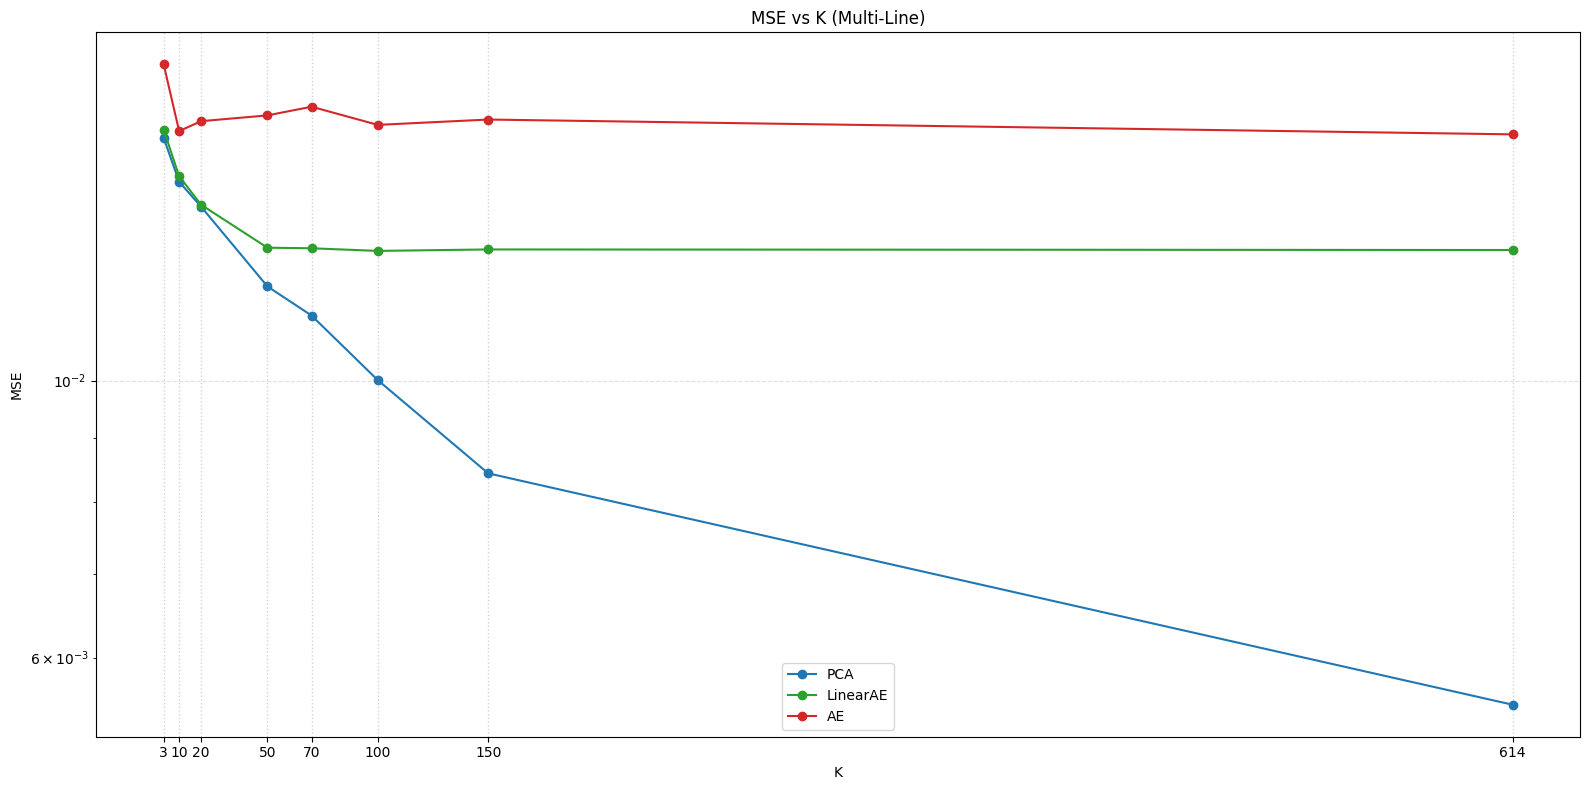

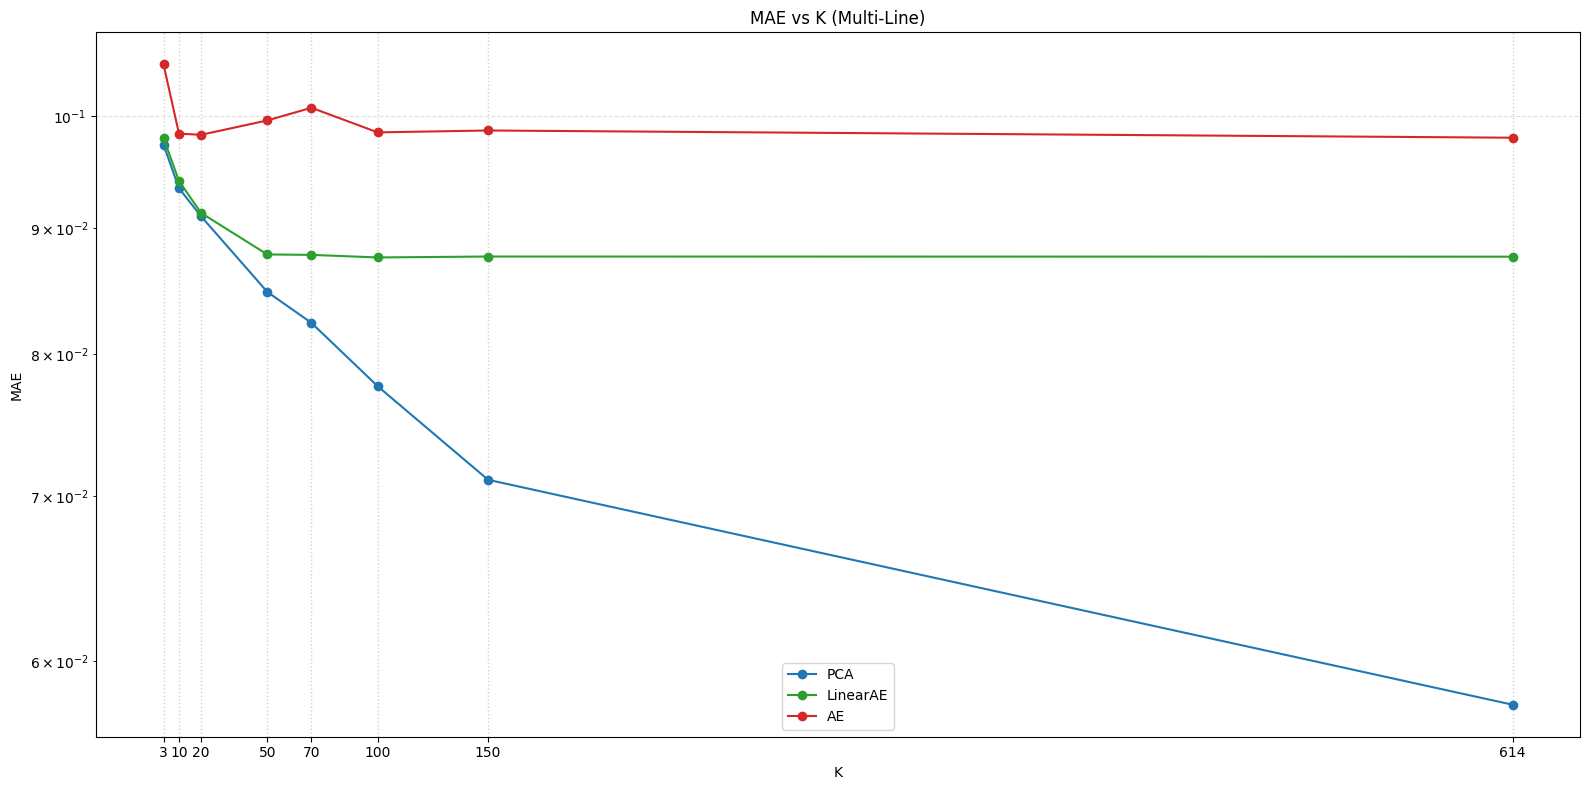

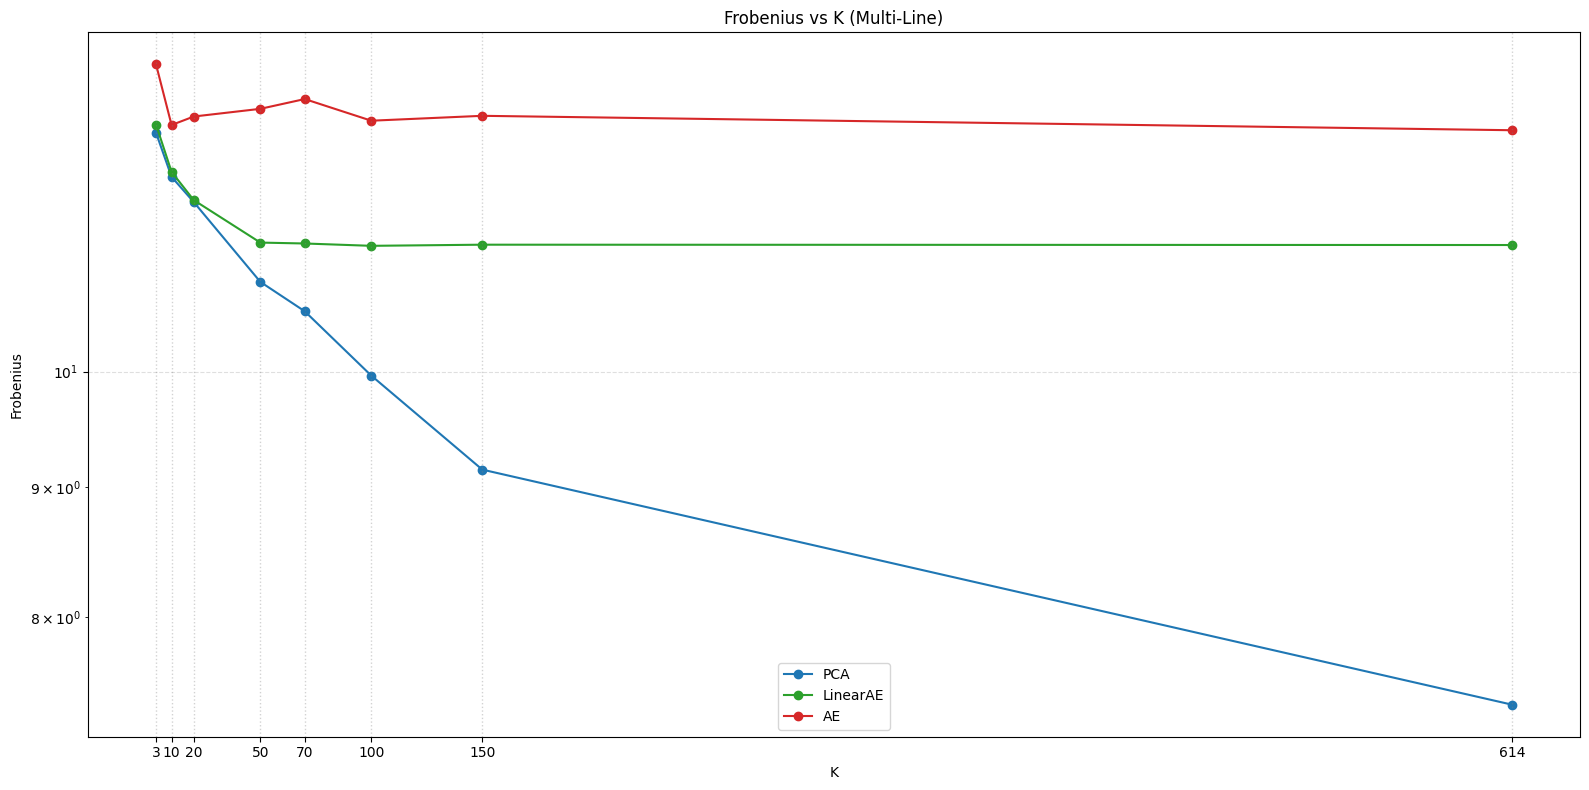

In [71]:
for metric in available_err_metrics:
    fig, ax = plt.subplots(figsize=(16, 8))
    all_x = []
    all_y = []
    for method in methods:
        subset = err_long[
            (err_long["metric"] == metric) & (err_long["method"] == method)
        ].sort_values("K")
        x_vals = subset["K"].to_numpy()
        y_vals = subset["error"].to_numpy()
        all_x.extend(x_vals.tolist())
        all_y.extend(y_vals.tolist())
        ax.plot(
            x_vals,
            y_vals,
            marker="o",
            label=method_labels.get(method, method),
            color=method_colors.get(method),
        )

    ax.set_title(f"{metric} vs K (Multi-Line)")
    ax.set_xlabel("K")
    ax.set_ylabel(metric)
    ax.set_yscale("log")
    if all_x:
        k_ticks = sorted(set(all_x))
        ax.set_xticks(k_ticks)
        for k_tick in k_ticks:
            ax.axvline(
                k_tick,
                linestyle=":",
                color="gray",
                alpha=0.35,
                linewidth=1,
            )
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.legend()
    plt.tight_layout()
    plot_path = comparison_dir / f"err_{metric}_vs_k.png"
    fig.savefig(plot_path, dpi=200, bbox_inches="tight")
    plt.show()

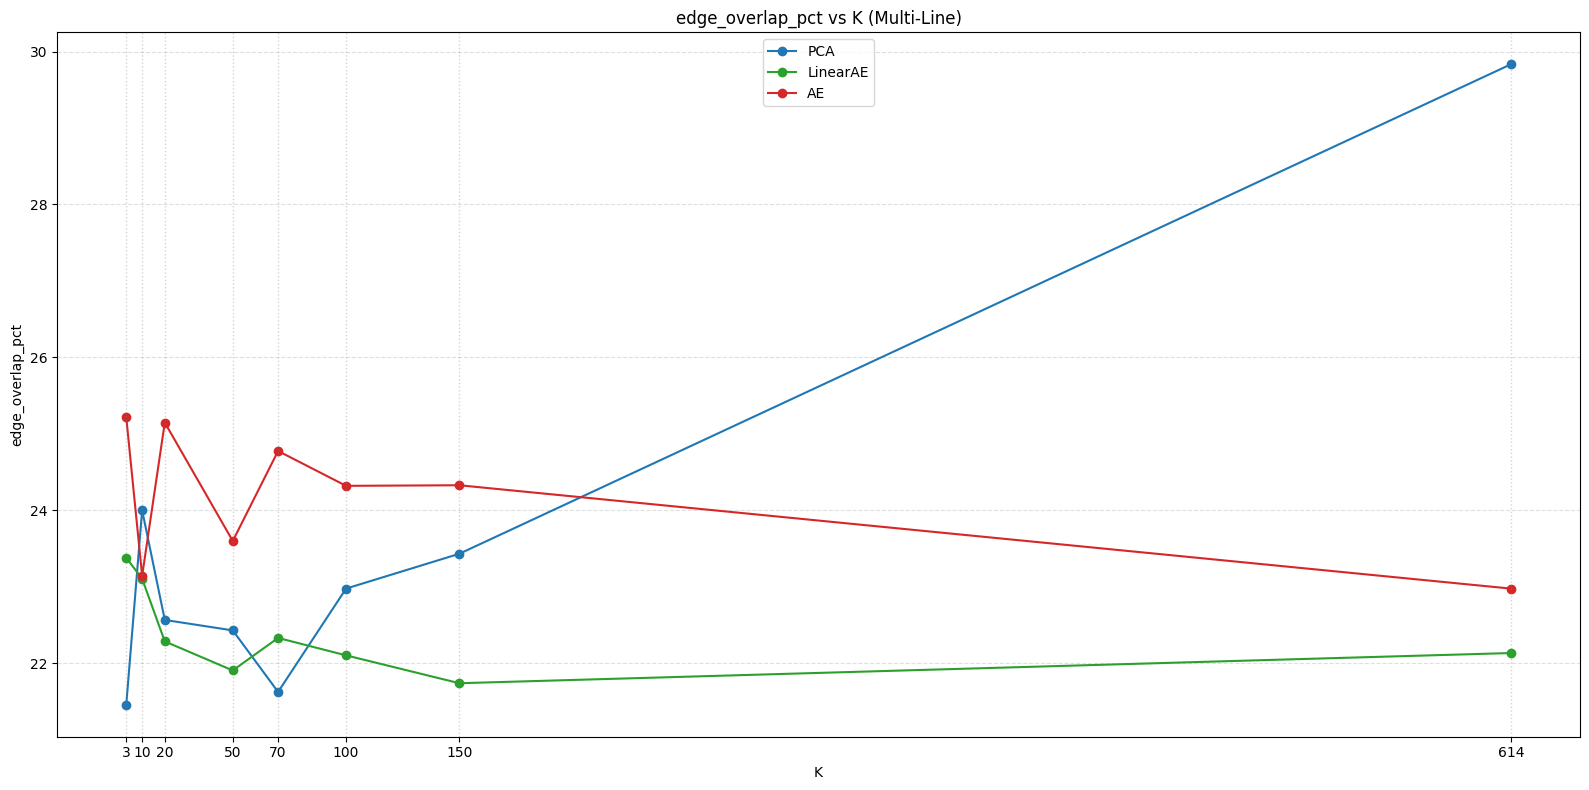

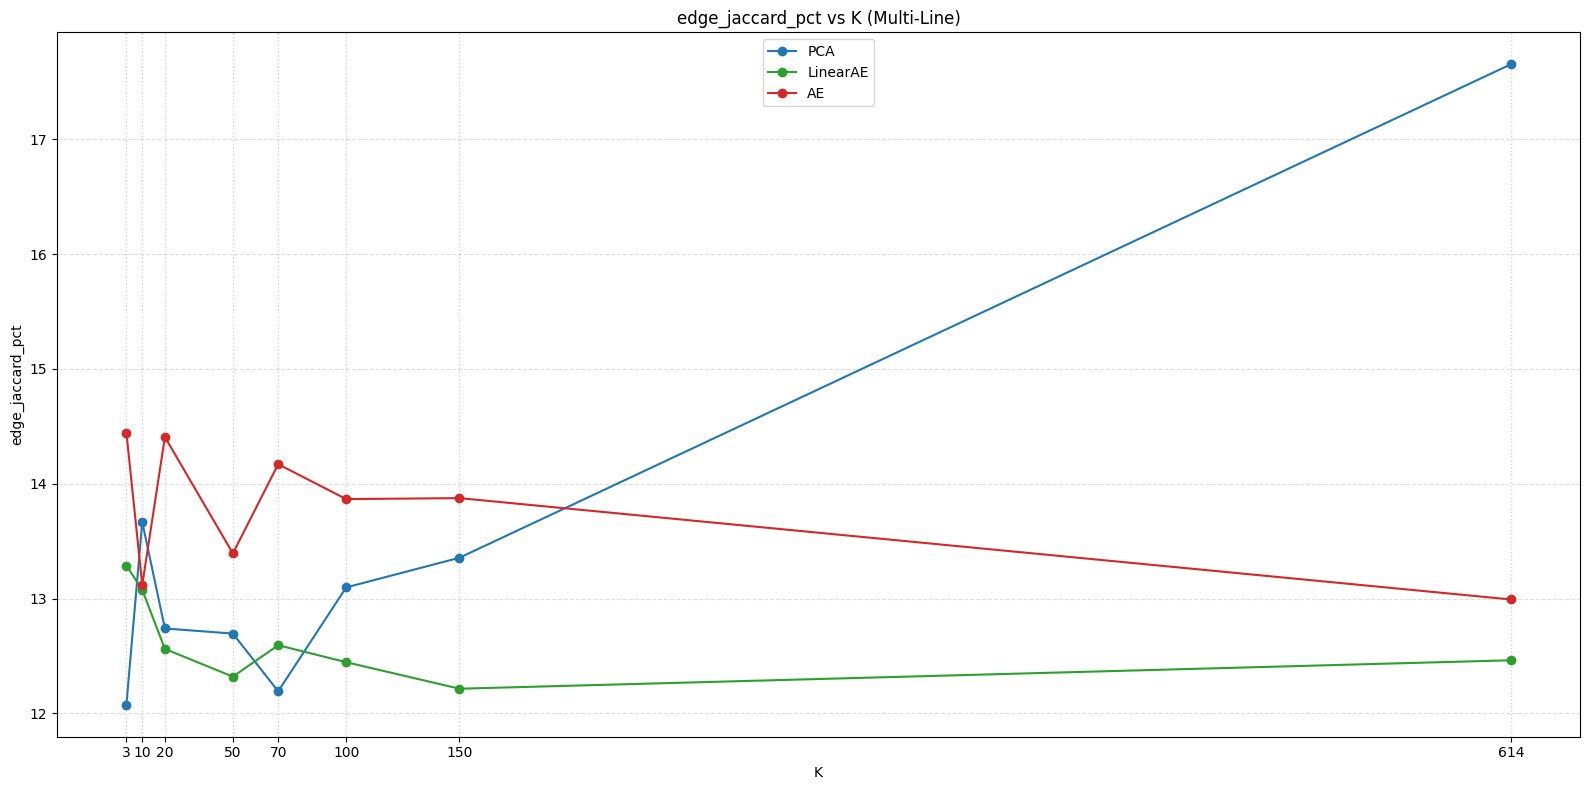

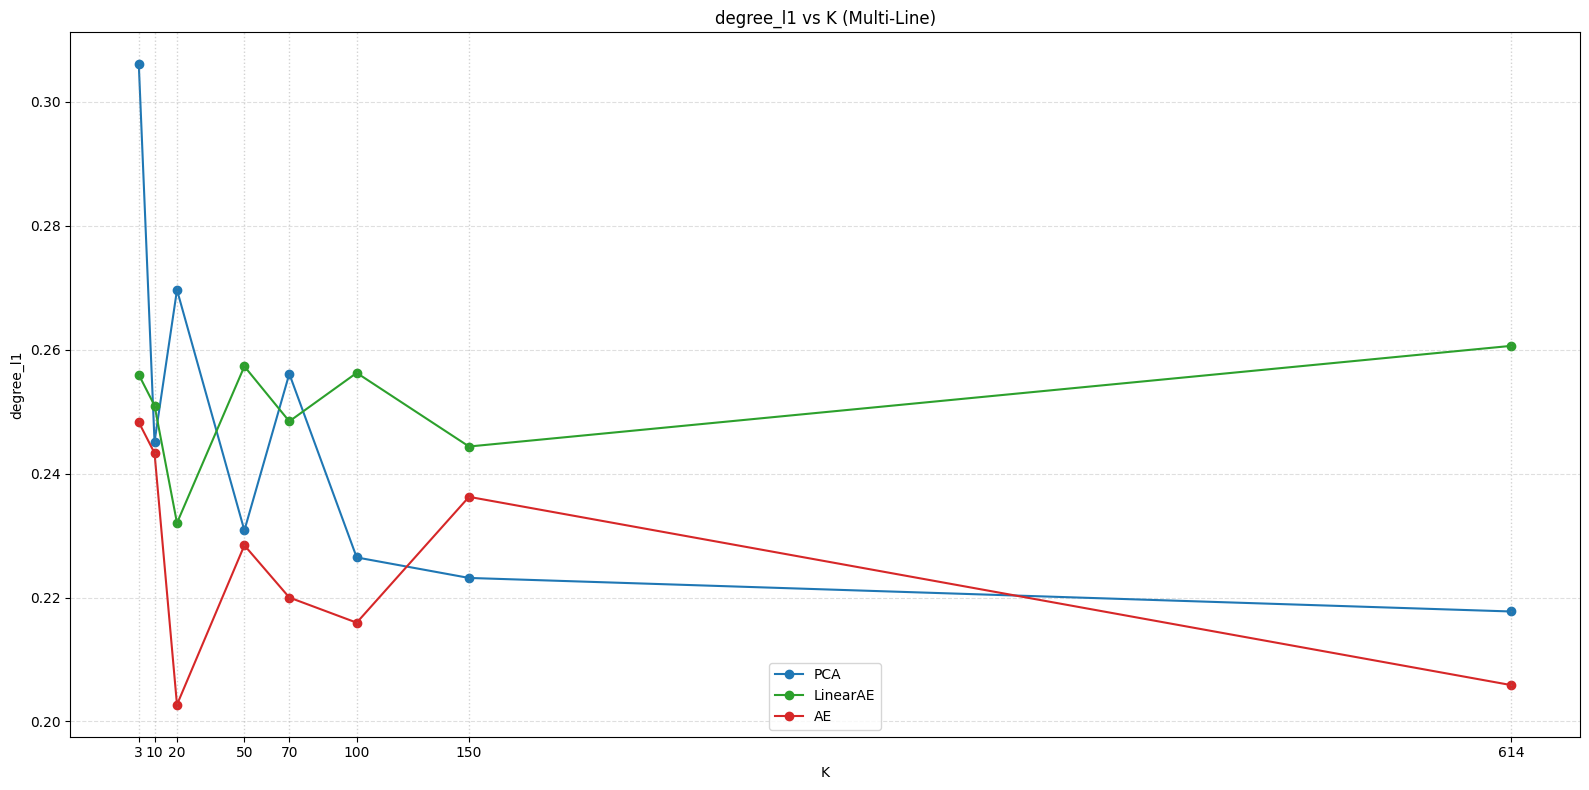

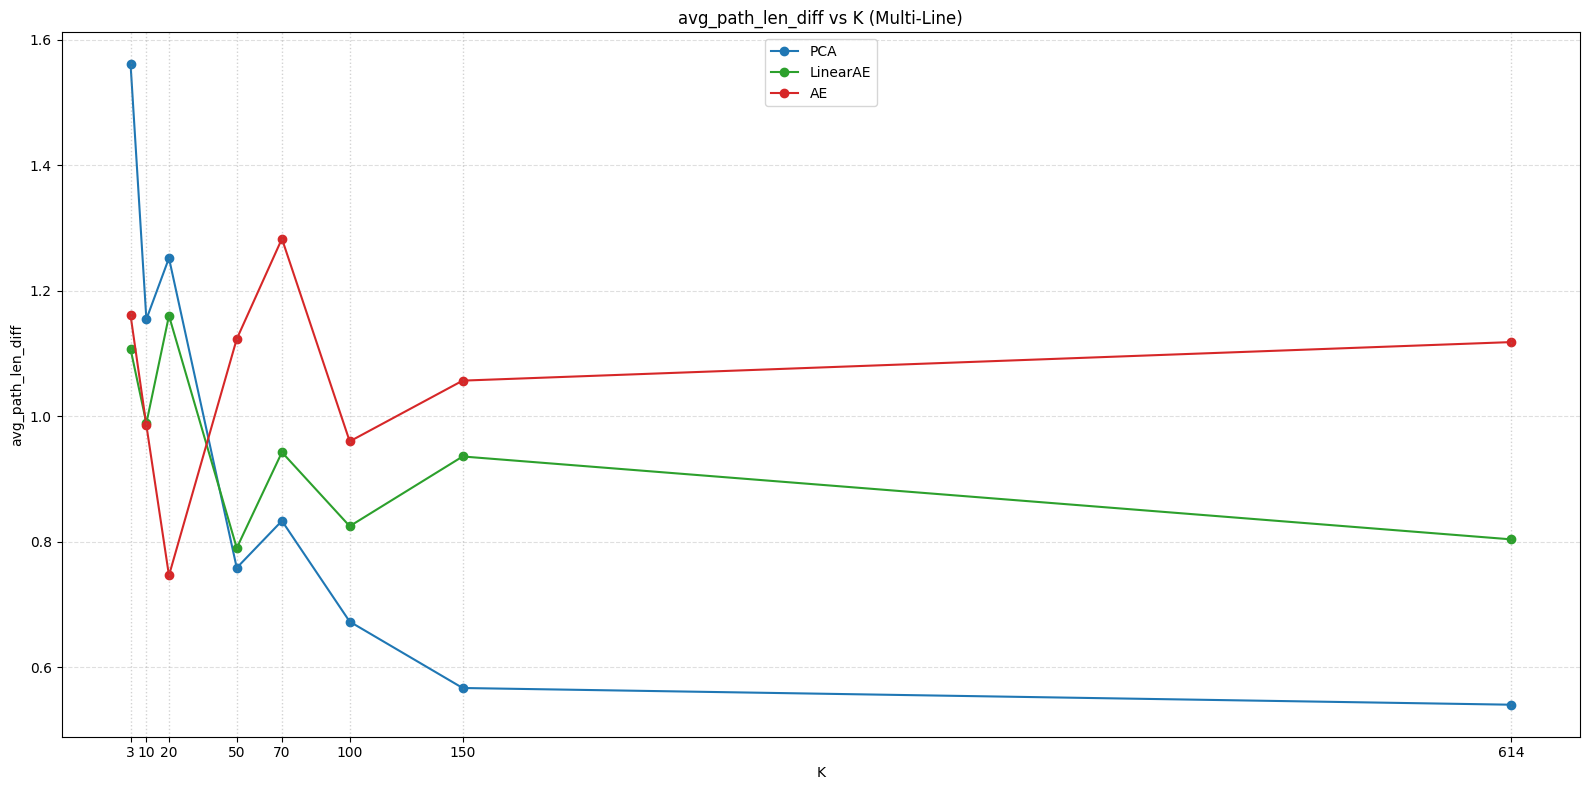

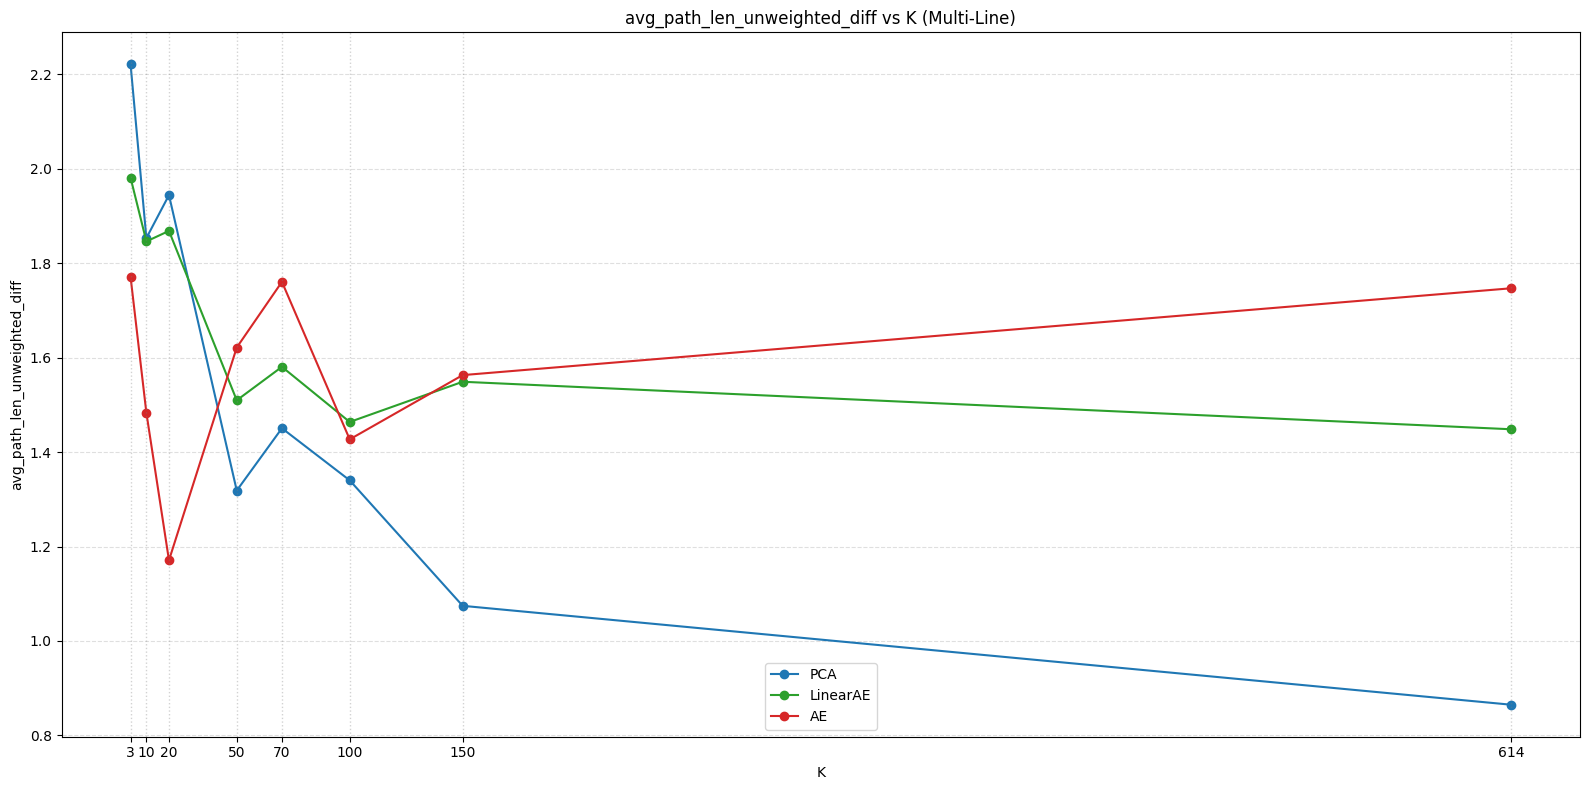

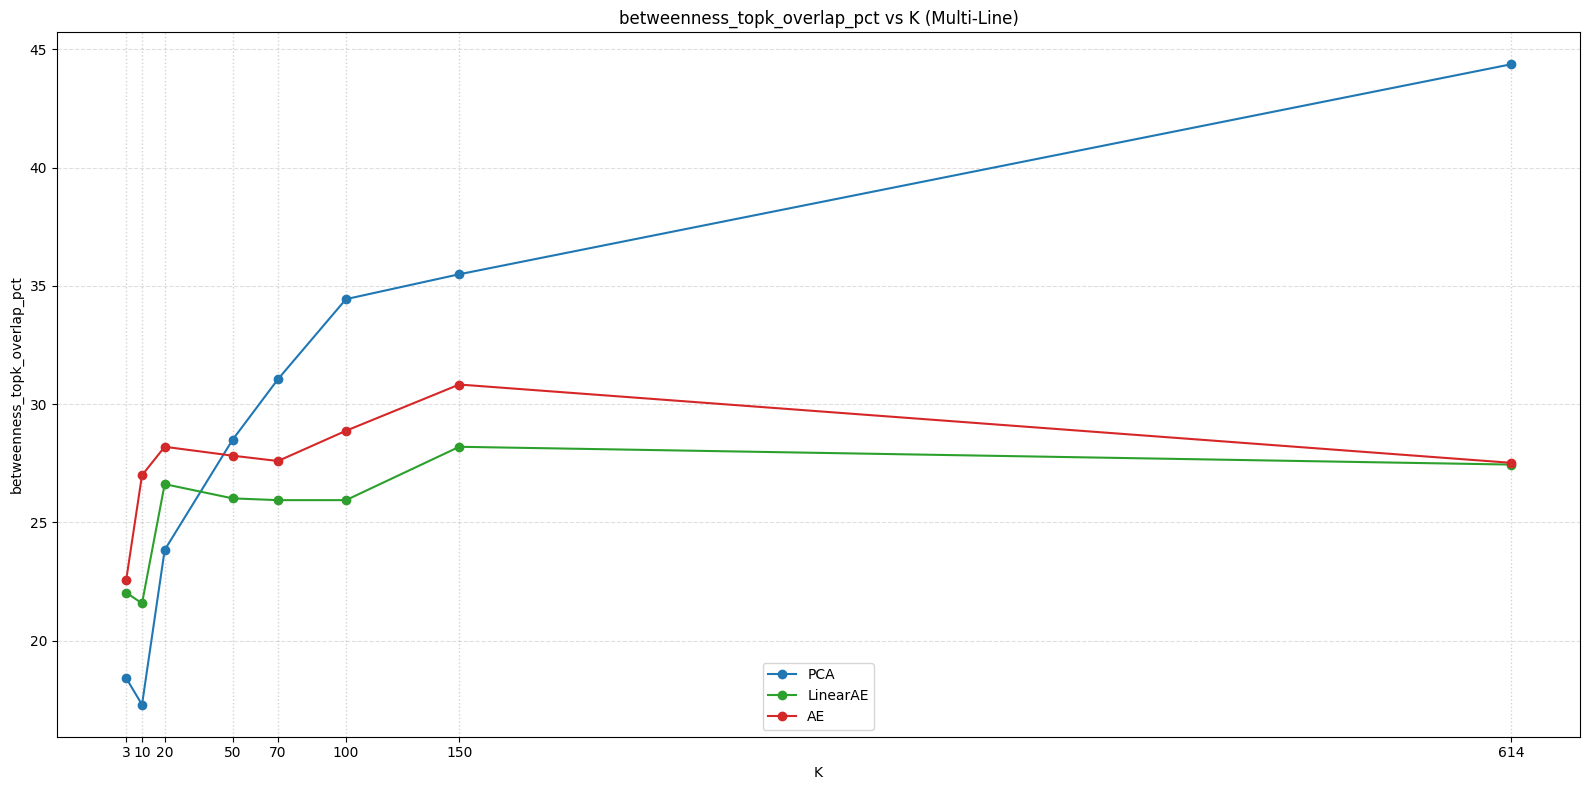

In [72]:
# MST K-based comparison plots
mst_by_model = mst_means.join(meta_df)
mst_by_model = mst_by_model.dropna(subset=["K", "method"]).copy()
mst_by_model["K"] = mst_by_model["K"].astype(int)

if mst_by_model.empty:
    raise ValueError("No valid MST models with parsed K were found.")

mst_long = mst_by_model.melt(
    id_vars=["method", "K"],
    value_vars=available_mst_metrics,
    var_name="metric",
    value_name="value",
)

mst_methods = [m for m in method_order if m in mst_long["method"].unique()]
if not mst_methods:
    mst_methods = sorted(mst_long["method"].unique())

mst_ks_sorted = sorted(mst_long["K"].unique())

for metric in available_mst_metrics:
    fig, ax = plt.subplots(figsize=(16, 8))
    all_x = []
    all_y = []
    for method in mst_methods:
        subset = mst_long[
            (mst_long["metric"] == metric) & (mst_long["method"] == method)
        ].sort_values("K")
        if subset.empty:
            continue
        x_vals = subset["K"].to_numpy()
        y_vals = subset["value"].to_numpy()
        all_x.extend(x_vals.tolist())
        all_y.extend(y_vals.tolist())
        ax.plot(
            x_vals,
            y_vals,
            marker="o",
            label=method_labels.get(method, method),
            color=method_colors.get(method),
        )

    ax.set_title(f"{metric} vs K (Multi-Line)")
    ax.set_xlabel("K")
    ax.set_ylabel(metric)
    if all_x:
        k_ticks = sorted(set(all_x))
        ax.set_xticks(k_ticks)
        for k_tick in k_ticks:
            ax.axvline(
                k_tick,
                linestyle=":",
                color="gray",
                alpha=0.35,
                linewidth=1,
            )
    if all_y:
        y_min = min(all_y)
        y_max = max(all_y)
        if y_min > 0 and (y_max / y_min) >= 1000:
            ax.set_yscale("log")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.legend()
    plt.tight_layout()
    plot_path = comparison_dir / f"mst_{metric}_vs_k.png"
    fig.savefig(plot_path, dpi=200, bbox_inches="tight")
    plt.show()